In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#importing seaborn for statistical plots
import seaborn as sns
# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

In [2]:
A=pd.read_csv('kc_house_data.csv')
A.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
A.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [4]:
#Maximum square feet living is 13,450 where as the minimum is 290. we can see that the data is distributed.
#the dataset has a house where the house has 33 bedrooms

In [5]:
def check_null(data):
    null_col_list=[]
    for col in data:
        if data[col].isnull().sum() >0:
            null_col_list.append(col)
        else:
            pass
    return null_col_list

null_col_list=check_null(A)
print("Columns with Null Values = {0}".format(null_col_list))



Columns with Null Values = []


In [6]:
# There is no null values.

<function seaborn.utils.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=False, offset=None, trim=False)>

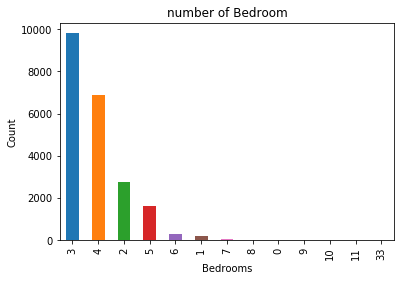

In [7]:
A['bedrooms'].value_counts().plot(kind='bar')
plt.title('number of Bedroom')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
sns.despine


In [8]:
# there are more three bedroom house.

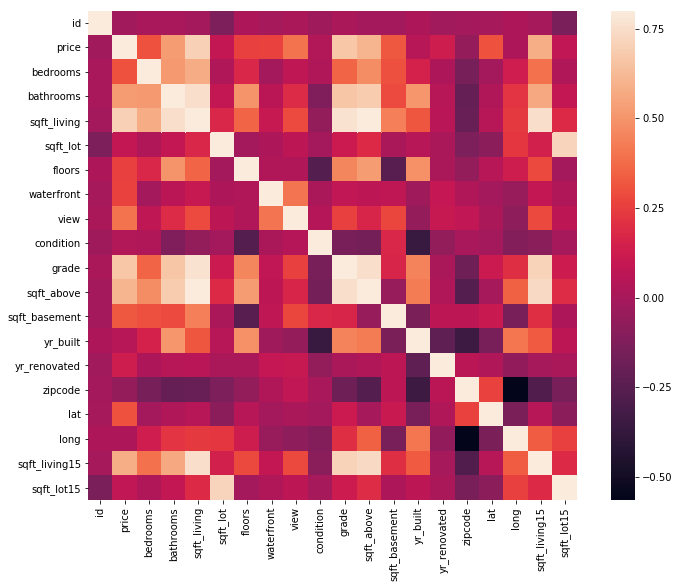

In [9]:
corrmat = A.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

# Factors affecting Prices

Text(0.5, 1.0, 'Price vs Square Feet')

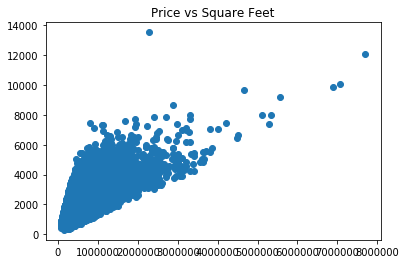

In [10]:
plt.scatter(A.price,A.sqft_living)
plt.title("Price vs Square Feet")

Text(0.5, 1.0, 'Price vs Location of the area')

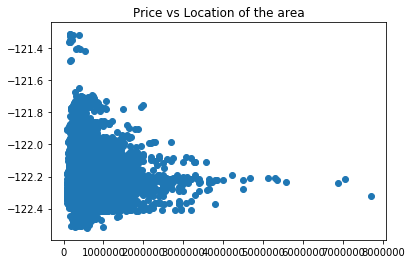

In [11]:
plt.scatter(A.price,A.long)
plt.title("Price vs Location of the area")

Text(0.5, 1.0, 'Latitude vs Price')

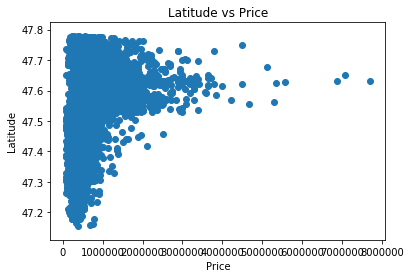

In [12]:

plt.scatter(A.price,A.lat)
plt.xlabel("Price")
plt.ylabel('Latitude')
plt.title("Latitude vs Price")

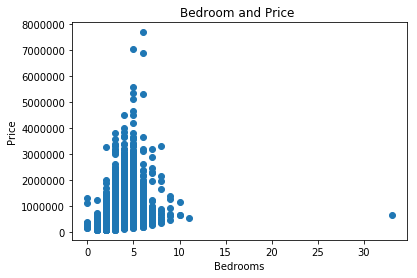

<function seaborn.utils.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=False, offset=None, trim=False)>

In [13]:
plt.scatter(A.bedrooms,A.price)
plt.title("Bedroom and Price ")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()
sns.despine

Text(0.5, 1.0, 'Which is the pricey location by zipcode?')

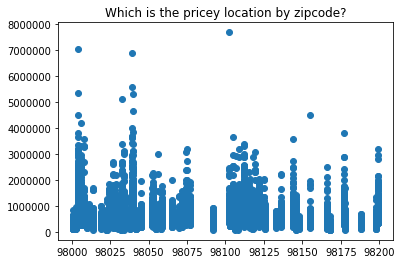

In [14]:
plt.scatter(A.zipcode,A.price)
plt.title("Which is the pricey location by zipcode?")

In [15]:
from sklearn.linear_model import LinearRegression

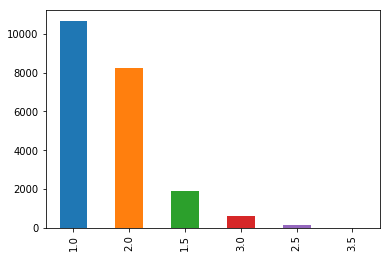

In [20]:
A.floors.value_counts().plot(kind='bar')


In [21]:
reg = LinearRegression()

In [38]:
X = A['price']
conv_dates = [1 if values == 2014 else 0 for values in A.date ]
A['date'] = conv_dates
Y = A.drop(['id', 'price'],axis=1)

In [39]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.3,random_state=1)


In [59]:
Xtrain.dtypes

dtype('float64')

In [41]:
reg.fit(x_train,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [42]:
reg.score(x_test,y_test)

0.7320342760357841

In [43]:
reg.coef_

array([ 0.00000000e+00, -3.69584689e+04,  3.99944474e+04,  1.12442724e+02,
        1.05110204e-01,  6.09005604e+03,  6.03577974e+05,  5.14093954e+04,
        2.61292108e+04,  9.39146205e+04,  7.03934445e+01,  4.20492792e+01,
       -2.56363788e+03,  1.97755242e+01, -5.81262588e+02,  6.06931004e+05,
       -2.14720057e+05,  2.18724560e+01, -3.52080103e-01])

In [44]:
reg.intercept_


6286489.366111042

In [46]:
y_pred=reg.predict(Xtest)
rmse=np.sqrt(np.mean((ytest-ypred)**2))
rmse

ValueError: Expected 2D array, got 1D array instead:
array=[ 459000.  445000. 1057000. ...  230000. 1680000.  293000.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [48]:
reg.score(Xtest,ytest)

ValueError: Expected 2D array, got 1D array instead:
array=[ 459000.  445000. 1057000. ...  230000. 1680000.  293000.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [50]:
c=np.arange(len(reg.coef_))

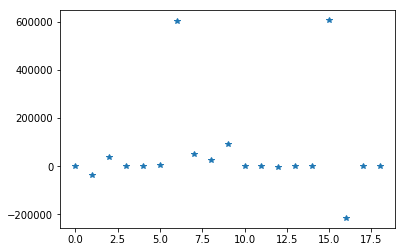

In [52]:
plt.plot(c,reg.coef_,'*')

In [53]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [54]:
rd=Ridge(alpha=0.5,normalize=True)
Ls=Lasso(alpha=0.05,normalize=True)

In [55]:
rd.fit(Xtrain,ytrain)
rd_pred=rd.predict(Xtest)
Ls.fit(Xtrain,ytrain)
Ls_pred=Ls.predict(Xtest)

ValueError: Expected 2D array, got 1D array instead:
array=[ 272500.  206000.   82000. ...  650000.  437000. 1025000.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [56]:
from sklearn.metrics import mean_squared_error
rd_rmse=np.sqrt(mean_squared_error(ytest,rd_pred))
rd_rmse

NameError: name 'rd_pred' is not defined

In [60]:
kf=KFold(n_splits=3,shuffle=True,random_state=2)
for model, name in zip([LR,Ridge_R,Lasso_R],['MVLR','Ridge','Lasso']):
    rmse=[]
    for train,test in kf.split(X,Y):
        Xtrain,Xtest=X.iloc[train,:],X.iloc[test,:]
        Ytrain,Ytest=Y.iloc[train],Y.iloc[test]
        model.fit(Xtrain,Ytrain)
        Y_predict=model.predict(Xtest)
        rmse.append(np.sqrt(metrics.mean_squared_error(Ytest,Y_predict)))
    print(rmse)
    print("Cross_Validated_rmse_score: %0.03f (+/- %0.5f) [%s]" % (np.mean(rmse),np.var(rmse,ddof=1),name)) 

NameError: name 'KFold' is not defined